# EDA (Exploratory Data Analysis)
Thực hành trên bộ dữ liệu về xe hơi

## 1. Hiểu tổng quan về bộ dữ liệu


*EDA = mô tả + trực quan để lấy insight; chưa suy nhân quả, chưa huấn luyện mô hình.*

### 1.1. Đọc dữ liệu từ file csv và hiển thị 5 dòng dữ liệu đầu tiên.

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
df = pd.read_csv('dataCAR.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### 1.2. Hiển thị 5 dòng dữ liệu cuối cùng

In [3]:
df.tail()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


### 1.3. Hiển thị kiểu dữ liệu của từng cột

In [5]:
df.dtypes

Make                     str
Model                    str
Year                   int64
Engine Fuel Type         str
Engine HP            float64
Engine Cylinders     float64
Transmission Type        str
Driven_Wheels            str
Number of Doors      float64
Market Category          str
Vehicle Size             str
Vehicle Style            str
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

#### Câu hỏi ôn tập: Định nghĩa mục tiêu & nạp dữ liệu (Stage 1)

**Câu 1 (Tự luận):** Viết 3 ý: (1) bạn muốn biết gì từ dữ liệu xe, (2) kết quả phục vụ ai, (3) thế nào là phân tích “đủ tốt” ở bước EDA (ví dụ: mô tả được giá, thấy quan hệ HP–Price…).

**Câu 2 (Trắc nghiệm):** Câu nào **SAI**?
- A. Chồng thêm dòng khi hai bảng **cùng cột** (ví dụ xe năm này + năm kia)
- B. Ghép hai bảng **theo khóa** (ví dụ hồ sơ xe + bảng giá theo mẫu)
- C. Đọc CSV và đọc Excel đều là nạp **một** bảng
- D. Hai cách ghép bảng ở A và B **luôn** cho ra kết quả giống nhau, không cần phân biệt

**Câu 3 (Trắc nghiệm):** Trước khi EDA, dữ liệu dạng bảng (mỗi dòng là một quan sát, mỗi cột là một biến) được **nhập** vào pandas thành DataFrame. Câu nào **đúng**?
- A. Chỉ định dạng CSV mới đọc được thành DataFrame
- B. Có thể nhập từ nhiều định dạng và nguồn: CSV (`read_csv`), Excel (`read_excel`), hoặc bảng lấy từ kho dữ liệu (Kaggle Hub, cơ sở dữ liệu…) rồi đọc thành DataFrame. Định dạng và nguồn khác nhau; thao tác nhập thì cùng mục đích
- C. Định dạng Excel không dùng được trong EDA
- D. Phải ghép bảng (`merge`) trước thì mới đọc được tệp CSV


**Đáp án – Câu hỏi ôn tập (Stage 1: mục tiêu & nạp dữ liệu)**

**Câu 1.** (1) Muốn biết giá xe (`Price`) phân bố ra sao và những yếu tố nào đi cùng giá: HP, số xi-lanh, năm sản xuất, hãng, hộp số. (2) Kết quả phục vụ người mua/bán xe, đại lý hoặc nhóm làm mô hình dự đoán giá về sau. (3) Phân tích "đủ tốt" ở bước EDA khi dữ liệu đã sạch (hết trùng, hết ô trống, xử lý outlier có lý do), mô tả được phân phối của `Price`, `HP`, thấy được quan hệ HP–Price và ghi lại được các giới hạn của dữ liệu.

**Câu 2.** **D**

**Câu 3.** **B** 


## 2. Tiền xử lý dữ liệu

### 2.1. Xóa đi các cột không quan tâm
Hãy xóa các cột: 'Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'
Sau đó, hiển thị lại 5 dòng dữ liệu đầu tiên

In [6]:
cols_drop = ['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size']
df = df.drop(columns=cols_drop)
df.head()

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


### 2.2. Đổi tên các cột để ngắn gọn hơn

Đổi tên các cột như sau:

"Engine HP": "HP",

"Engine Cylinders": "Cylinders",

"Transmission Type": "Transmission",

"Driven_Wheels": "Drive Mode",

"highway MPG": "MPG-H",

"city mpg": "MPG-C",

"MSRP": "Price"

Sau đó, hiển thị lại 5 dòng dữ liệu đầu tiên

In [7]:
df = df.rename(columns={
    "Engine HP": "HP",
    "Engine Cylinders": "Cylinders",
    "Transmission Type": "Transmission",
    "Driven_Wheels": "Drive Mode",
    "highway MPG": "MPG-H",
    "city mpg": "MPG-C",
    "MSRP": "Price"
})
df.head()

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


#### Câu hỏi ôn tập: Data Wrangling (Stage 1)

Pipeline: **Discovery → Structuring → Cleaning → Enriching → Validating → Publishing**

**Câu 1 (Trắc nghiệm):** Xóa cột không dùng và đổi tên (`Engine HP` → `HP`) thuộc bước nào?
- A. Discovery
- B. Structuring
- C. Enriching
- D. Publishing

**Câu 2:** Kéo mỗi việc vào đúng bước (viết Discovery / Structuring / Cleaning / Enriching / Validating / Publishing):
- xem `head`, hiểu ý nghĩa cột
- đổi tên cột, bỏ cột thừa
- xử lý trùng, ô trống, giá trị lỗi
- tạo biến mới (ví dụ tuổi xe từ `Year`)
- kiểm tra lại `shape`, missing, biểu đồ
- xuất bảng sạch để dùng tiếp

**Câu 3 (Tự luận):** Vì sao nên chuẩn hóa tên cột trước khi vẽ / thống kê? Rủi ro nếu báo cáo dùng tên cũ trong khi bảng đã đổi tên?

**Đáp án – Data Wrangling**

**Câu 1.** **B** 

**Câu 2.**
- xem `head`, hiểu ý nghĩa cột → **Discovery**
- đổi tên cột, bỏ cột thừa → **Structuring**
- xử lý trùng, ô trống, giá trị lỗi → **Cleaning**
- tạo biến mới (tuổi xe từ `Year`) → **Enriching**
- kiểm tra lại `shape`, missing, biểu đồ → **Validating**
- xuất bảng sạch để dùng tiếp → **Publishing**

**Câu 3.** Tên cột ngắn, thống nhất (`HP`, `Price`...) giúp code gọn, ít gõ sai và biểu đồ có nhãn dễ đọc. Nếu báo cáo hoặc code vẫn dùng tên cũ (`Engine HP`, `MSRP`) trong khi bảng đã đổi tên thì sẽ gặp `KeyError`, hoặc tệ hơn là nhầm cột giữa các phiên bản khiến số liệu trong báo cáo không khớp bảng đang dùng.


### 2.3. Xử lý dữ liệu trùng lặp

#### Hiển thị số dòng và số cột của bảng dữ liệu

In [8]:
print("Số dòng, số cột:", df.shape)

Số dòng, số cột: (11914, 10)


#### Hiển thị các dòng dữ liệu bị trùng

In [9]:
print("Số dòng trùng:", df.duplicated().sum())
df[df.duplicated()]

Số dòng trùng: 989


,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
14,BMW,1 Series,2013,230.0,6.0,MANUAL,rear wheel drive,28,19,31500
18,Audi,100,1992,172.0,6.0,MANUAL,front wheel drive,24,17,2000
20,Audi,100,1992,172.0,6.0,MANUAL,front wheel drive,24,17,2000
24,Audi,100,1993,172.0,6.0,MANUAL,front wheel drive,24,17,2000
25,Audi,100,1993,172.0,6.0,MANUAL,front wheel drive,24,17,2000
...,...,...,...,...,...,...,...,...,...,...
11481,Suzuki,X-90,1998,95.0,4.0,MANUAL,four wheel drive,26,22,2000
11603,Volvo,XC60,2017,302.0,4.0,AUTOMATIC,all wheel drive,29,20,46350
11604,Volvo,XC60,2017,240.0,4.0,AUTOMATIC,front wheel drive,30,23,40950
11708,Suzuki,XL7,2008,252.0,6.0,AUTOMATIC,all wheel drive,22,15,29149


#### Hiển thị số lượng giá trị phân biệt (khác nhau đôi một) của từng cột dữ liệu

In [10]:
df.nunique()

Make              48
Model            915
Year              28
HP               356
Cylinders          9
Transmission       5
Drive Mode         4
MPG-H             59
MPG-C             69
Price           6049
dtype: int64

#### Xóa đi những dữ liệu bị trùng lặp

**Câu hỏi gợi ý:**
1. Vì sao cần xóa dòng trùng trước khi phân tích / mô hình hóa? Nếu giữ nguyên, các chỉ số như trung bình `Price`, tần suất `Make` sẽ bị ảnh hưởng thế nào?
2. Khi xóa trùng, mặc định nên giữ dòng nào: dòng đầu, dòng cuối, hay xóa hết các bản sao? Khi nào nên đổi cách giữ?
3. Có phải mọi xe cùng `Make`, `Year`, `HP` đều là dữ liệu lỗi? Khi nào nên xét trùng theo **toàn bộ dòng**, khi nào nên xét trùng theo **một số cột**?

**Trả lời câu hỏi gợi ý**

1. Dòng trùng làm một xe bị đếm nhiều lần, nên trung bình `Price` và tần suất `Make` bị lệch về phía các xe bị lặp. Khi chia train/test sau này, cùng một dòng có thể nằm ở cả hai phía và làm kết quả đẹp giả. Ở bộ này có **989 dòng trùng** (11.914 → 10.925 dòng).
2. Mặc định giữ dòng **đầu tiên** (`keep='first'`) vì các bản sao giống hệt nhau nên giữ dòng nào cũng như nhau. Dùng `keep='last'` khi dữ liệu có thứ tự thời gian và bản sau là bản cập nhật; dùng `keep=False` khi muốn loại hẳn các bản ghi nghi ngờ lỗi để kiểm tra lại.
3. Không. Nhiều xe cùng `Make`, `Year`, `HP` vẫn là các phiên bản khác nhau (khác kiểu thân xe, hộp số, giá). Xét trùng theo **toàn bộ dòng** khi cần loại bản ghi lặp; chỉ xét theo **một số cột** (`subset`) khi các cột đó thật sự là khóa định danh của một bản ghi.


In [11]:
df = df.drop_duplicates()   # mặc định keep='first'
print("Sau khi xóa trùng:", df.shape)

Sau khi xóa trùng: (10925, 10)


#### Xử lý dữ liệu trùng lặp

**Câu 1 (Trắc nghiệm):** Hàm `df.drop_duplicates()` mặc định sẽ làm gì?
- A. Xóa tất cả các dòng xuất hiện nhiều hơn một lần, không giữ lại dòng nào
- B. Giữ lại dòng trùng **đầu tiên** (`keep='first'`), xóa các dòng giống hẹt phía sau
- C. Giữ lại dòng trùng **cuối cùng** (`keep='last'`)
- D. Chỉ đánh dấu trùng, không xóa dòng nào

**Câu 2 (Trắc nghiệm):** Sau khi xóa trùng, `nunique()` của từng cột thường thay đổi như thế nào?
- A. Giảm vì mỗi giá trị phân biệt bị xóa hết
- B. Tăng vì bảng dữ liệu có thêm cột mới
- C. Không đổi (hoặc gần như không đổi): số giá trị khác nhau vẫn giữ, chỉ giảm số dòng lặp
- D. Luôn bằng 0 vì dữ liệu đã bị làm sạch

**Câu 3 (Tự luận ngắn):** Giả sử hai dòng xe có cùng `Make`, `Year`, `HP`, `Cylinders` nhưng **khác `Price`**. Đó có phải là dòng trùng cần xóa bằng `drop_duplicates()` không? Nếu dùng `drop_duplicates(subset=['Make','Year','HP'])` thì rủi ro là gì đối với phân tích giá xe?

**Câu 4 (Tự luận phản biện):** Trên tập car, nhiều dòng trùng có thể là **cùng một mẫu xe được ghi hai lần** (lỗi thu thập), hoặc là **hai xe giống cấu hình thật**. Theo bạn, với mục tiêu EDA và dự đoán `Price`, nên xóa trùng toàn cục hay giữ lại? Hãy nêu **một lợi ích** và **một rủi ro** của việc xóa.

**Đáp án**

**Câu 1.** **B**. 
**Câu 2.** **C** 

**Câu 3.** Không, hai dòng khác `Price` là hai bản ghi khác nhau nên `drop_duplicates()` mặc định không xóa. Nếu dùng `subset=['Make','Year','HP']` thì ta xóa nhầm các phiên bản xe khác nhau (khác giá), làm mất biến thiên giá và còn phụ thuộc vào việc dòng nào đứng đầu, nên giá trung bình và quan hệ giá–cấu hình có thể bị sai lệch.

**Câu 4.** Với EDA và dự đoán giá nên **xóa trùng toàn bộ dòng** (chỉ xóa những dòng giống hệt ở mọi cột). *Lợi ích*: trung bình, tần suất không bị đếm gấp và tránh rò rỉ dữ liệu giữa train/test. *Rủi ro*: bộ dữ liệu không có mã định danh (VIN), nên có thể ta xóa nhầm vài xe có cấu hình thật sự giống hệt nhau và làm mất một ít thông tin về mức độ phổ biến.


#### Hiển thị lại số lượng giá trị phân biệt (khác nhau đôi một) của từng cột dữ liệu

In [12]:
df.nunique()

Make              48
Model            915
Year              28
HP               356
Cylinders          9
Transmission       5
Drive Mode         4
MPG-H             59
MPG-C             69
Price           6049
dtype: int64

### 2.4. Xử lý dữ liệu rỗng

1. Ô trống xuất hiện vì sao: ngẫu nhiên hoàn toàn, phụ thuộc cột khác đã thấy, hay phụ thuộc chính giá trị bị giấu?
2. Cột **số**, ít trống, **không phải** biến cần dự đoán, phân phối lệch: nên điền trung bình hay trung vị?
3. Cột **chữ / nhãn**: nên điền thế nào?
4. Khi nào nên **bỏ dòng** (thiếu biến mục tiêu, giá trị không hợp lệ, quá nhiều dòng trống) thay vì điền? Sau khi bỏ dòng, chỉ số dòng có thể lệch — bạn xử lý ra sao?
5. Nhiều ô “không muốn nêu”: gán nhãn riêng hay thay bằng giá trị phổ biến nhất?

**Trả lời câu hỏi gợi ý**

1. Phải đoán cơ chế thiếu: MCAR (ngẫu nhiên hoàn toàn), MAR (phụ thuộc cột khác đã quan sát) hoặc MNAR (phụ thuộc chính giá trị bị giấu). Ở bộ này `Cylinders` thiếu chủ yếu ở xe điện (Bolt EV, e-Golf, i-MiEV, RAV4 EV) và xe động cơ xoay Mazda RX-7/RX-8, tức là thiếu có quy luật (MAR); `HP` thiếu tập trung ở Tesla, Ford, Nissan, Lincoln.
2. Điền **trung vị** vì phân phối lệch, trung bình bị kéo bởi giá trị cực lớn.
3. Điền **mode** (giá trị phổ biến nhất), hoặc nhãn riêng như `Unknown` nếu muốn giữ thông tin "không rõ".
4. Bỏ dòng khi thiếu biến mục tiêu, giá trị không hợp lệ hoặc thiếu quá nhiều. Sau khi bỏ cần `reset_index(drop=True)` để chỉ số dòng liên tục.
5. Nếu "không muốn nêu" là một nhóm có ý nghĩa thì **gán nhãn riêng**; thay bằng mode sẽ làm nhóm đó biến mất vào nhóm đông nhất.


#### Hiển thị số lượng giá trị rỗng của từng cột dữ liệu

In [13]:
df.isnull().sum()

Make             0
Model            0
Year             0
HP              69
Cylinders       30
Transmission     0
Drive Mode       0
MPG-H            0
MPG-C            0
Price            0
dtype: int64

#### Xóa đi các giá trị rỗng, sau đó hiển thị lại số lượng giá trị phân biệt của từng cột.

In [14]:
df = df.dropna().reset_index(drop=True)
print("Sau khi xóa dòng rỗng:", df.shape)
df.nunique()

Sau khi xóa dòng rỗng: (10827, 10)


Make              47
Model            904
Year              28
HP               355
Cylinders          9
Transmission       5
Drive Mode         4
MPG-H             44
MPG-C             50
Price           6014
dtype: int64

#### Hiển thị lại số lượng giá trị rỗng của từng cột dữ liệu

In [15]:
df.isnull().sum()

Make            0
Model           0
Year            0
HP              0
Cylinders       0
Transmission    0
Drive Mode      0
MPG-H           0
MPG-C           0
Price           0
dtype: int64

#### Câu hỏi ôn tập: Missingness & cách xử lý ô trống (Stage 1)

**Câu 1 (Trắc nghiệm):** Ô trống ở `HP` xuất hiện hoàn toàn ngẫu nhiên (lỗi đường truyền khi cào web), không phụ thuộc thuộc tính xe. Đây là:
- A. MAR
- B. MNAR
- C. MCAR
- D. Không thuộc các cơ chế trên

**Câu 2 (Trắc nghiệm):** `Cylinders` trống chủ yếu ở xe điện vì xe điện không dùng xi-lanh — thiếu **phụ thuộc cột đã quan sát** (loại nhiên liệu / xe điện). Đây là:
- A. MCAR
- B. MAR
- C. MNAR
- D. Cả A và B

**Câu 3 (Tự luận):** MNAR là gì? Ví dụ với `Price` (người bán giấu giá vì xe quá rẻ/quá đắt). Vì sao điền **trung bình** cho `Price` trong trường hợp này làm lệch bản chất dữ liệu?

**Câu 4 (Trắc nghiệm):** Cột số, **ít** trống, **không phải** biến mục tiêu, phân phối **lệch**. Stage 1 gợi ý điền bằng gì?
- A. Trung bình (mean)
- B. Trung vị (median)
- C. Mode của cột chữ
- D. Luôn xóa hết dòng

**Câu 5 (Trắc nghiệm):** Cột chữ / phân loại (`Transmission`, `Make`) thiếu vài ô. Ưu tiên điền:
- A. Mean
- B. Median
- C. Mode 
- D. IQR

**Câu 6 (Trắc nghiệm):** Khi nào nên **xóa dòng** rồi **đặt lại chỉ số dòng**, thay vì điền?
- A. Thiếu biến mục tiêu (`Price`), giá trị không hợp lệ (ví dụ năm = −1), hoặc quá nhiều dòng trống
- B. Chỉ khi thiếu đúng 1 ô số
- C. Khi muốn giữ nguyên mọi dòng bằng mọi giá
- D. Khi biến là phân loại và muốn giữ nhãn đặc biệt

**Câu 7 (Tự luận):** Nhiều ô kiểu “không muốn nêu / Unknown”. Nên gán nhãn **Unknown** hay thay bằng mode? Vì sao mode có thể **giấu** nhóm người từ chối trả lời?

**Câu 8:** Với từng cột còn trống, hãy tự quyết định: điền (mean / median / mode / Unknown) hay xóa dòng. Viết **lý do 1 câu / cột**. Nhớ: `Price` là mục tiêu thì thiếu `Price` thường **không** điền lung tung.

**Đáp án**
**Câu 1.** **C**
**Câu 2.** **B**.
**Câu 3.** MNAR là thiếu phụ thuộc chính giá trị bị thiếu (ví dụ người bán giấu giá vì xe quá rẻ hoặc quá đắt). Khi đó các ô thiếu không phải mẫu ngẫu nhiên của `Price`; điền trung bình sẽ kéo các xe cực rẻ/cực đắt về giữa, làm phân phối co lại và sai lệch bản chất dữ liệu.
**Câu 4.** **B**
**Câu 5.** **C**
**Câu 6.** **A**
**Câu 7.** Nên gán nhãn **Unknown**. Thay bằng mode sẽ biến những người từ chối trả lời thành người thuộc nhóm đông nhất, khiến tỷ lệ nhóm đó bị phóng đại và ta không còn phân biệt được "đã khai" với "không muốn khai". Giữ `Unknown` còn cho phép kiểm tra xem nhóm này có hành vi khác biệt hay không.
**Câu 8.** Các cột còn trống sau bước xóa trùng:
- `HP` (69 ô, ~0,6%): ít, nên **xóa dòng** (hoặc điền trung vị theo từng `Make` nếu muốn giữ), vì `HP` là biến giải thích quan trọng của giá.
- `Cylinders` (30 ô): **xóa dòng**; không điền trung bình vì xe điện không có xi-lanh, điền số nào cũng vô nghĩa.
- `Price`: không thiếu; nếu thiếu thì xóa dòng vì là biến mục tiêu.
- `Transmission`: không thiếu ô trống nhưng có 11 dòng nhãn `UNKNOWN`, nên **giữ nhãn riêng**.
Kết quả: xóa 98 dòng, còn 10.827 dòng.


### 2.5. Xử lý outlier

**Câu hỏi gợi ý:**
1. Boxplot cho `Price`, `HP`, `Cylinders` cho thấy gì (trung vị, khoảng giữa, điểm nằm ngoài)?
2. Độ trải giữa (IQR) dùng để xác định ngưỡng thế nào?
3. Ngoài **xóa** điểm lệch, còn **cắt về ngưỡng** và **kéo cực trị vào percentile**. Khác nhau ở chỗ nào (số dòng, giá trị bị đổi)? Khi nào nên xóa, khi nào nên giữ siêu xe?

**Trả lời câu hỏi gợi ý**

1. Boxplot cho thấy trung vị (vạch giữa hộp), khoảng giữa Q1–Q3 (hộp) và các điểm nằm ngoài "râu" là outlier. `Price` và `HP` đều lệch phải với rất nhiều điểm cao; `Cylinders` tập trung ở 4–6 xi-lanh, các điểm 10, 12, 16 nằm ngoài.
2. IQR = Q3 − Q1. Ngưỡng dưới = Q1 − 1,5×IQR, ngưỡng trên = Q3 + 1,5×IQR; giá trị ngoài hai ngưỡng bị coi là outlier.
3. **Xóa**: số dòng giảm, giá trị cực trị biến mất. **Clip**: giữ nguyên số dòng, giá trị vượt ngưỡng bị thay bằng đúng ngưỡng. **Winsorize**: giữ nguyên số dòng, giá trị cực trị bị kéo về một percentile (ví dụ 1% và 99%). Nên xóa khi outlier là lỗi nhập liệu hoặc khi mục tiêu chỉ là xe phổ thông; nên giữ (hoặc clip) khi siêu xe là xe thật và ta muốn mô tả cả thị trường.


#### Vẽ boxplot cho cột Price

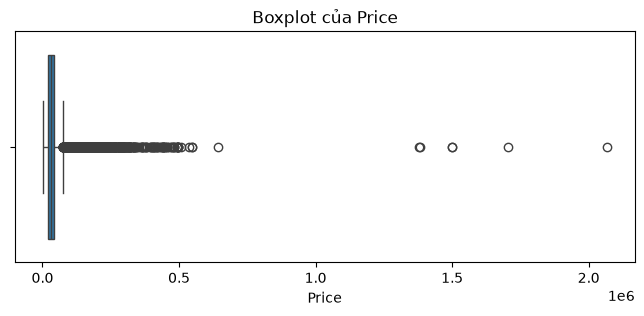

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Price'])
plt.title('Boxplot của Price')
plt.show()

#### Vẽ boxplot cho cột HP

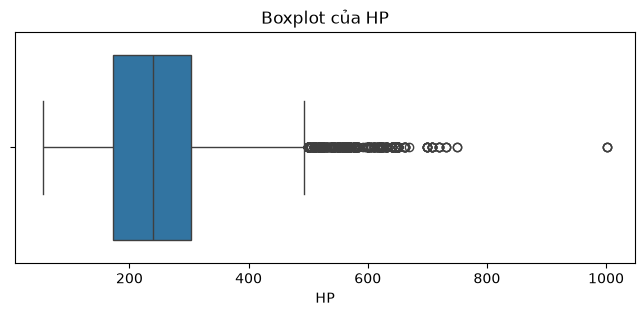

In [21]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['HP'])
plt.title('Boxplot của HP')
plt.show()

####  Vẽ boxplot cho cột Cylinders

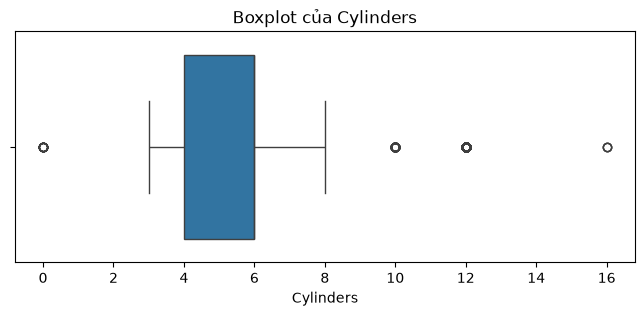

In [22]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Cylinders'])
plt.title('Boxplot của Cylinders')
plt.show()

#### Tìm độ trải giữa (IQR) của từng cột dữ liệu

In [23]:
num_cols = ['Price', 'HP', 'Cylinders']
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
bounds = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR,'Ngưỡng dưới': Q1 - 1.5 * IQR,'Ngưỡng trên': Q3 + 1.5 * IQR})
bounds['Số outlier'] = [((df[c] < bounds.loc[c, 'Ngưỡng dưới']) | (df[c] > bounds.loc[c, 'Ngưỡng trên'])).sum() for c in num_cols]
bounds

,Q1,Q3,IQR,Ngưỡng dưới,Ngưỡng trên,Số outlier
Price,21972.5,43300.0,21327.5,-10018.75,75291.25,936
HP,173.0,303.0,130.0,-22.00,498.00,495
Cylinders,4.0,6.0,2.0,1.00,9.00,309


#### Loại bỏ đi outlier

In [24]:
mask = pd.Series(True, index=df.index)
for c in num_cols:
    mask &= df[c].between(bounds.loc[c, 'Ngưỡng dưới'], bounds.loc[c, 'Ngưỡng trên'])
print("Số dòng bị loại:", (~mask).sum())
df = df[mask].reset_index(drop=True)
print("Kích thước sau khi loại outlier:", df.shape)

Số dòng bị loại: 991
Kích thước sau khi loại outlier: (9836, 10)


#### Câu hỏi ôn tập: Outlier & IQR (Stage 1)

**Câu 1 (Trắc nghiệm):** Một giá trị X của `Price` bị coi là outlier theo IQR (hệ số 1.5) khi:
- A. X < Q1 − 1.5 × IQR hoặc X > Q3 + 1.5 × IQR
- B. Q1 − 1.5 × IQR ≤ X ≤ Q3 + 1.5 × IQR
- C. X < Q1 − 3 × IQR hoặc X > Q3 + 3 × IQR
- D. X > Median + 1.5 × IQR

**Câu 2 (Trắc nghiệm):** Sau khi phát hiện outlier, Stage 1 nêu ba hướng. Câu nào **đúng**?
- A. Chỉ được xóa (drop); clip / winsorize là sai
- B. Có thể xóa, hoặc **clip** (cắt về ngưỡng), hoặc **winsorize** (kéo cực trị vào percentile) — tùy mục tiêu
- C. Winsorize luôn xóa dòng
- D. Clip luôn làm tăng số dòng

**Câu 3 (Tự luận):** Phân biệt **xóa** outlier, **clip**, và **winsorize** (số dòng còn lại đổi thế nào? giá trị cực trị bị thay hay bị bỏ?). Với mục tiêu hiểu **xe phổ thông**, bạn chọn hướng nào cho `Price`? Với mục tiêu mô tả **cả thị trường gồm siêu xe**, chọn hướng nào?

**Câu 4 (Tự luận phản biện):** Xóa theo IQR trên toàn bảng có thể mất Bugatti / Ferrari vì `Price` rất cao. Nên hay không nên? Việc này giúp gì / hại gì nếu sau này chỉ muốn dự đoán giá xe phổ thông?

**Câu 5 (Ôn — làm được):** Tự tính IQR cho các cột số, chỉ ra ngưỡng dưới/trên, và giải thích trước khi xóa: cột nào outlier là lỗi, cột nào outlier là xe thật.

**Đáp án – Outlier & IQR**

**Câu 1.** **A**
**Câu 2.** **B**.

**Câu 3.** *Xóa* làm giảm số dòng và bỏ hẳn giá trị cực trị. *Clip* giữ số dòng, thay giá trị vượt ngưỡng bằng chính ngưỡng. *Winsorize* giữ số dòng, kéo cực trị về percentile (ví dụ P1/P99). Với mục tiêu hiểu **xe phổ thông**, chọn **xóa** outlier `Price` (đúng như đã làm ở bài này). Với mục tiêu mô tả **cả thị trường gồm siêu xe**, chọn **giữ** hoặc **winsorize/clip** để vẫn giữ các dòng siêu xe nhưng không để vài giá trị cực lớn (cao nhất hơn 2 triệu USD) làm méo trung bình.

**Câu 4.** Với mục tiêu dự đoán giá xe phổ thông thì **nên** loại, vì Bugatti/Ferrari làm trung bình và độ lệch chuẩn bị kéo lên và mô hình bị chi phối bởi vài điểm cực đoan. Cái hại là mô hình sau đó **không dùng được cho siêu xe**, và ta mất thông tin về cả hãng (Ferrari, Lamborghini, Bentley, Aston Martin bị loại gần hết). Vì vậy phải ghi rõ phạm vi áp dụng của kết quả.

**Câu 5.**
Hầu hết outlier ở đây là **xe thật**, không phải lỗi: `Price`/`HP` cao thuộc về Ferrari, Lamborghini, Bentley, Aston Martin, Porsche, Mercedes-Benz, BMW; `Cylinders` = 10, 12, 16 là xe hiệu năng cao. Điểm đáng nghi duy nhất là `Cylinders` = 0 (xe điện/động cơ xoay, không phải xe 0 xi-lanh) và ngưỡng dưới âm của `Price`/`HP` thì không có ý nghĩa thực tế vì không có giá trị âm. Sau khi loại, còn **9.836 dòng** (mất 991 dòng).


## 3. Trực quan hóa dữ liệu

**Gợi ý ôn:** biến số → phân phối; biến nhóm → đếm tần suất; hai biến số → scatter; nhiều cột số → heatmap; so sánh phân phối theo nhóm → box/violin. Khi các hãng có **số mẫu khác nhau**, cân nhắc **tỷ lệ** chứ đừng chỉ đếm. Chỉnh tiêu đề, trục, nhiều plot một hình, lưu ảnh — cần kiểm soát figure/axes, không chỉ gọi lệnh vẽ nhanh.

### 3.1. Vẽ histogram cho cột Make

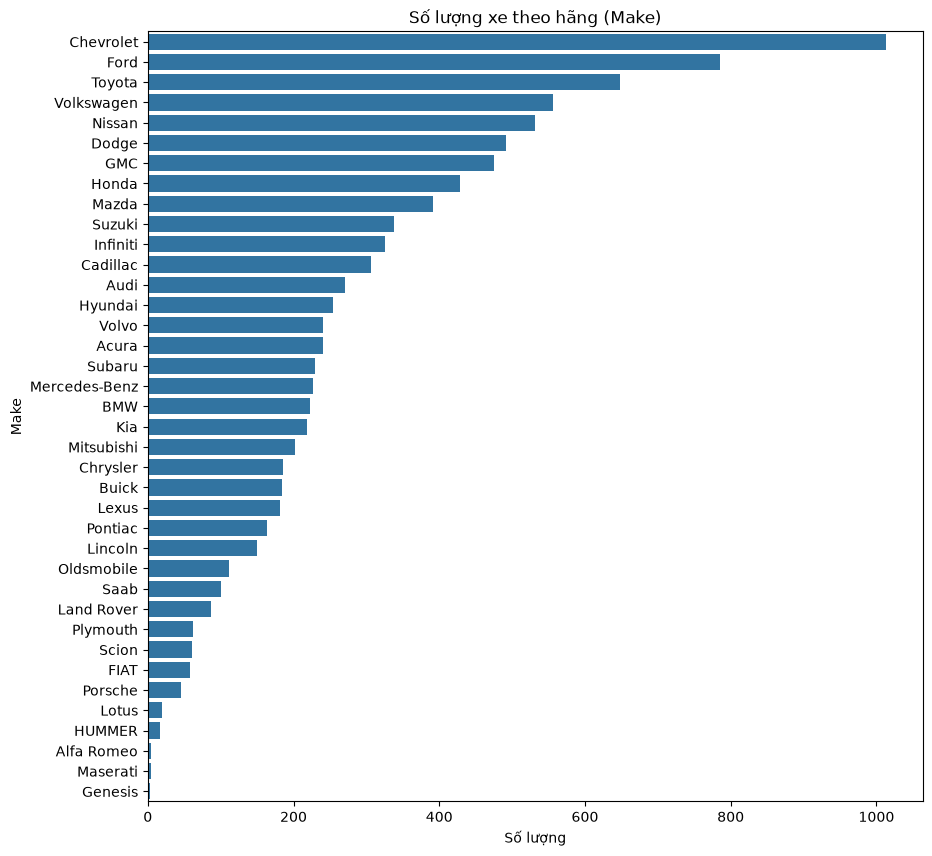

In [25]:
plt.figure(figsize=(10, 10))
sns.countplot(y='Make', data=df, order=df['Make'].value_counts().index)
plt.title('Số lượng xe theo hãng (Make)')
plt.xlabel('Số lượng')
plt.show()

### 3.2. Vẽ biểu đồ nhiệt

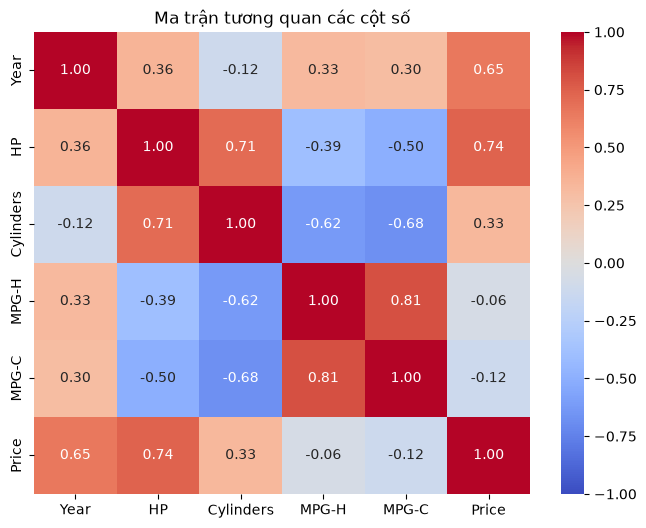

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan các cột số')
plt.show()

### 3.3. Vẽ biểu đồ scatter cho Price và HP

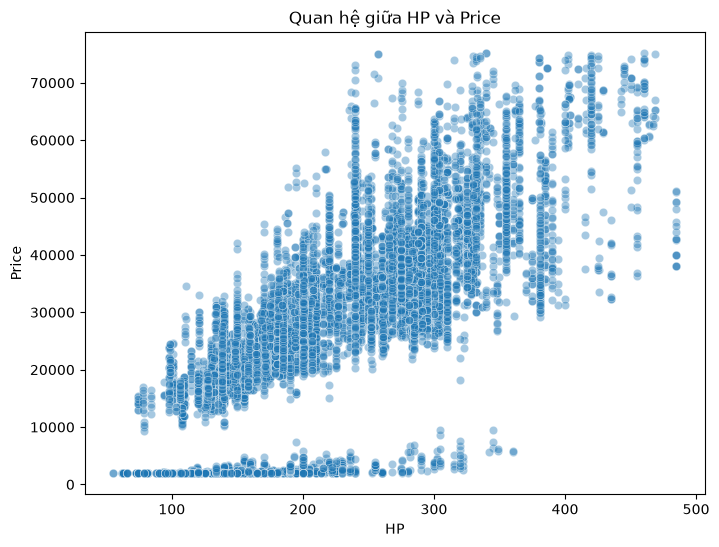

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='HP', y='Price', data=df, alpha=0.4)
plt.title('Quan hệ giữa HP và Price')
plt.show()

#### Câu hỏi ôn tập: EDA 6 bước & trực quan (Stage 1)

**Nhắc:** EDA = mô tả + trực quan để lấy *insight*. Chưa kết luận nhân quả, chưa huấn luyện mô hình.

**Câu 1 (Trắc nghiệm):** Mục tiêu đúng của EDA là gì?
- A. Chứng minh HP **gây ra** giá xe
- B. Mô tả phân phối và quan hệ để hiểu dữ liệu; chưa nhân quả, chưa ML
- C. Chỉ cần đủ để chạy hồi quy là xong
- D. Thay thế toàn bộ kiểm định giả thuyết

**Câu 2 (Trắc nghiệm):** `Make` là biến **phân loại** (hãng xe). Biểu đồ nào **phù hợp hơn** để xem tần suất từng hãng?
- A. Histogram (dành phân phối biến số)
- B. Biểu đồ đếm theo nhóm (bar / countplot)
- C. Heatmap tương quan
- D. Scatter `Price` vs `HP`

**Câu 3 (Tự luận):** Chevrolet có **nhiều dòng** hơn Alfa Romeo. Nếu chỉ soánh **số lượng** xe đắt theo hãng, kết luận có thể lệch ở đâu? Vì sao khi cỡ mẫu khác nhau nên nhìn **tỷ lệ (rate)** thay vì chỉ **count**?

**Câu 4 (Tự luận — làm được):** Với tập xe, bạn chọn loại biểu đồ nào cho từng nhu cầu? Viết 1 câu / nhu cầu, **không cần dán code**:
- phân phối `Price` hoặc `HP`
- tần suất `Transmission` hoặc `Make`
- quan hệ hai biến số `HP` và `Price`
- tương quan nhiều cột số (heatmap)
- so sánh phân phối giá theo nhóm (box / violin)

**Câu 5 (Trắc nghiệm — đúng/sai, chọn câu sai):** Về Matplotlib / Seaborn, câu **SAI** là:
- A. Seaborn vẽ nhanh từ DataFrame; vẫn dùng Matplotlib để chỉnh title, trục, layout, lưu ảnh
- B. Có hai kiểu viết: gọi trực tiếp `plt...` hoặc dùng `fig, ax = ...` (object-oriented)
- C. Seaborn **thay thế hoàn toàn** Matplotlib, không cần học `ax` / `plt` nữa
- D. Tô màu theo nhóm dùng `hue`; nhiều plot một figure dùng subplots

**Câu 6 (Tự luận ngắn — feature engineering):** Đề xuất **một** biến mới từ `Year`, **một** cách chia nhóm (bin) cho `HP` hoặc `Price`, và nêu vì sao biến phân loại như `Transmission` thường cần mã hóa (dummy) **nếu** sau này đưa vào mô hình. EDA bước này chưa bắt buộc scale — vì sao vẫn nên *biết* scaling là gì?

**Câu 7 (Tổng kết — làm được):** Viết **3 insight** từ biểu đồ (ví dụ: giá lệch, HP đi kèm giá, hãng nào chiếm nhiều mẫu…) và **1 caveat** (giới hạn: outlier siêu xe, dữ liệu cũ, hãng lệch số lượng, EDA không suy nhân quả).

**Đáp án – EDA & trực quan**

**Câu 1.** **B**
**Câu 2.** **B**
**Câu 5.** **C**
**Câu 3.** Chevrolet có nhiều dòng hơn nên gần như luôn có nhiều xe đắt hơn về số lượng, dù tỷ lệ xe đắt của hãng này có thể thấp. Nếu chỉ so count ta kết luận sai rằng Chevrolet "đắt hơn" Alfa Romeo. Với cỡ mẫu khác nhau nên nhìn **tỷ lệ** (số xe đắt / tổng xe của hãng) để so sánh công bằng.

**Câu 4.**
- Phân phối `Price`/`HP`: histogram (hoặc KDE) để xem hình dạng và độ lệch.
- Tần suất `Transmission`/`Make`: biểu đồ cột đếm (countplot).
- Quan hệ `HP` và `Price`: scatter plot.
- Tương quan nhiều cột số: heatmap của ma trận tương quan.
- So sánh phân phối giá theo nhóm: boxplot hoặc violin theo `Make`/`Transmission`.

**Câu 6.** Biến mới: `Age = 2017 − Year` (tuổi xe, dữ liệu kết thúc năm 2017). Chia nhóm: `HP` thành thấp (<150), trung bình (150–300), cao (>300), hoặc `Price` theo tứ phân vị. Biến phân loại như `Transmission` cần mã hóa dummy/one-hot vì mô hình chỉ nhận số, và one-hot tránh tạo thứ tự giả giữa các nhãn. Vẫn nên biết scaling vì `HP` (hàng trăm) và `Price` (hàng chục nghìn) khác thang đo rất xa; các mô hình dựa trên khoảng cách hoặc gradient (KNN, SVM, hồi quy có regularization) sẽ bị biến có thang lớn chi phối.

**Câu 7.**
- *Insight 1:* `Price` lệch phải rõ (trước khi loại outlier trung bình ≈ 42.493 USD, trung vị ≈ 30.845 USD).
- *Insight 2:* `HP` tương quan mạnh nhất với `Price` (r ≈ 0,74), tiếp theo là `Year` (r ≈ 0,65); xe nhiều xi-lanh đắt hơn (trung bình 4 xi-lanh ≈ 24.474 USD, 6 xi-lanh ≈ 32.806 USD, 8 xi-lanh ≈ 38.183 USD).
- *Insight 3:* `HP` và `Cylinders` tương quan nghịch với mức tiết kiệm nhiên liệu (r với `MPG-C` lần lượt ≈ −0,50 và −0,68), còn `MPG` hầu như không liên quan đến `Price`. Chevrolet (1.013), Ford (785) và Toyota (648) chiếm nhiều mẫu nhất.
- *Caveat:* đã loại siêu xe bằng IQR nên kết luận chỉ áp dụng cho xe phổ thông; dữ liệu chỉ đến 2017 nên giá đã cũ; số mẫu giữa các hãng rất lệch (Genesis 3, Maserati 4 so với Chevrolet 1.013); EDA chỉ mô tả tương quan, chưa suy ra nhân quả.


#BÀI TOÁN KIỂM ĐỊNH
1. CHO 1 BÀI TOÁN KIỂM ĐỊNH T-TEST
2. CHO 1 BÀI TOÁN KIỂM ĐỊNH Z-TEST
3. CHO 1 BÀI TOÁN KIỂM ĐỊNH CHI-SQUARE
4. CHO 1 BÀI TOÁN KIỂM ĐỊNH ANOVA

In [28]:
# 1. Bài toán kiểm định T-Test
# Câu hỏi nghiên cứu: Liệu giá cả trung bình của các xe có động cơ 6 xi lanh có khác biệt đáng kể so với giá cả trung bình của các xe có động cơ 4 xi lanh không?

# Giả thuyết null (H0): Giá cả trung bình của xe 6 xi lanh bằng giá cả trung bình của xe 4 xi lanh.
# Giả thuyết đối (H1): Giá cả trung bình của xe 6 xi lanh khác với giá cả trung bình của xe 4 xi lanh.

from scipy import stats

# Lọc dữ liệu cho xe có động cơ 4 và 6 xi lanh
cars_4_cylinders = df[df['Cylinders'] == 4]['Price']
cars_6_cylinders = df[df['Cylinders'] == 6]['Price']

# Thực hiện kiểm định T-Test
t_statistic, p_value = stats.ttest_ind(cars_4_cylinders, cars_6_cylinders)

# In kết quả
print(f"T-Statistic: {t_statistic}")
print(f"P-Value: {p_value}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Giá cả trung bình của xe 6 xi lanh khác với xe 4 xi lanh.")
else:
    print("Không bác bỏ H0: Giá cả trung bình của xe 6 xi lanh bằng với xe 4 xi lanh.")

T-Statistic: -27.460888867589222
P-Value: 5.738512830927822e-159
Bác bỏ H0: Giá cả trung bình của xe 6 xi lanh khác với xe 4 xi lanh.


In [30]:
# 2. Bài toán kiểm định Z-Test
# Câu hỏi nghiên cứu: Liệu giá trung bình của xe trong mẫu có khác biệt đáng kể so với mức giá trung bình đã biết của toàn bộ xe trên thị trường (giả sử là 30,000 USD)?

# Giả thuyết null (H0): Giá trung bình của xe trong mẫu bằng 30,000 USD.
# Giả thuyết đối (H1): Giá trung bình của xe trong mẫu khác với 30,000 USD.
import numpy as np
# Lấy giá cả của xe trong mẫu
sample_prices = df['Price']

# Tính toán các thông số cần thiết
sample_mean = np.mean(sample_prices)
sample_std = np.std(sample_prices, ddof=1)  # ddof=1 để tính độ lệch chuẩn mẫu
n = len(sample_prices)
known_mean = 30000  # Giá trung bình đã biết

# Tính giá trị Z
z_value = (sample_mean - known_mean) / (sample_std / np.sqrt(n))

# Tính giá trị p từ giá trị Z
p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))  # Nhân đôi để kiểm định hai phía

# In kết quả
print(f"Z-Value: {z_value}")
print(f"P-Value: {p_value}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Giá trung bình của xe trong mẫu khác với 30,000 USD.")
else:
    print("Không bác bỏ H0: Giá trung bình của xe trong mẫu bằng 30,000 USD.")

Z-Value: -1.6119256329606269
P-Value: 0.10697812350428926
Không bác bỏ H0: Giá trung bình của xe trong mẫu bằng 30,000 USD.


In [31]:
# 3. Bài toán kiểm định Chi-Square
# Câu hỏi nghiên cứu: Có sự liên quan nào giữa loại xe (Make) và kiểu truyền động (Transmission Type) không?

# Giả thuyết null (H0): Không có sự liên quan giữa loại xe và kiểu truyền động.
# Giả thuyết đối (H1): Có sự liên quan giữa loại xe và kiểu truyền động.

# Tạo bảng tần số cho loại xe và kiểu truyền động
contingency_table = pd.crosstab(df['Make'], df['Transmission'])

# In bảng tần số
print("Bảng tần số:")
print(contingency_table)

# Thực hiện kiểm định Chi-Square
chi2_statistic, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# In kết quả
print(f"\nChi-Square Statistic: {chi2_statistic}")
print(f"P-Value: {p_value}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies:\n{expected}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Có sự liên quan giữa loại xe và kiểu truyền động.")
else:
    print("Không bác bỏ H0: Không có sự liên quan giữa loại xe và kiểu truyền động.")

Bảng tần số:
Transmission   AUTOMATED_MANUAL  AUTOMATIC  DIRECT_DRIVE  MANUAL  UNKNOWN
Make                                                                     
Acura                        20        167             0      54        0
Alfa Romeo                    5          0             0       0        0
Audi                         98        126             0      47        0
BMW                           5        166             0      52        0
Buick                         0        184             0       0        0
Cadillac                      0        303             0       4        0
Chevrolet                     0        711             2     300        0
Chrysler                      0        167             0      16        2
Dodge                         0        328             0     163        1
FIAT                          0         22             0      36        0
Ford                         11        578             0     196        0
GMC                      

In [32]:
# 4. Bài toán kiểm định ANOVA
# Câu hỏi nghiên cứu: Liệu giá cả trung bình của các xe có sự khác biệt giữa các loại động cơ (ví dụ: động cơ 4, 6 và 8 xi lanh) không?

# Giả thuyết null (H0): Giá cả trung bình của xe giữa các loại động cơ là như nhau.
# Giả thuyết đối (H1): Ít nhất một trong các giá trị giá cả trung bình giữa các loại động cơ là khác nhau.

# Nhóm giá cả xe theo từng loại động cơ
grouped_data = [group['Price'].values for name, group in df.groupby('Cylinders')]

# Thực hiện kiểm định ANOVA
f_statistic, p_value = stats.f_oneway(*grouped_data)

# In kết quả
print(f"F-Statistic: {f_statistic}")
print(f"P-Value: {p_value}")

# Quyết định về giả thuyết
alpha = 0.05  # Mức ý nghĩa
if p_value < alpha:
    print("Bác bỏ H0: Có sự khác biệt giữa giá cả trung bình của các loại động cơ.")
else:
    print("Không bác bỏ H0: Giá cả trung bình của xe giữa các loại động cơ là như nhau.")

F-Statistic: 313.0912456151491
P-Value: 5.969819266311405e-254
Bác bỏ H0: Có sự khác biệt giữa giá cả trung bình của các loại động cơ.
